In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [24]:
df.shape

(8807, 12)

In [25]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [26]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


The dataset contains Netflix Movies and TV Shows.

It has information like title, director, country, rating and release year.

Some columns contain missing values.

The dataset includes content from many countries.

This dataset can be used to understand Netflix content trends.

# Dataset Summary

The Netflix Movies and TV Shows dataset contains information about content available on Netflix, including movies and TV shows. It includes attributes such as title, director, cast, country, release year, date added, rating, duration, and genre.

The dataset contains both categorical and numerical data. During the initial inspection, missing values were found in columns such as director, cast, country, date_added, and rating. Duplicate records were also checked before cleaning.

The objective of this project is to clean the dataset, perform exploratory data analysis (EDA), visualize important patterns, and generate business insights from the data.

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [12]:
df.drop_duplicates(inplace=True)

print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


In [17]:
df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [28]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed")

In [31]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [32]:
df = df.dropna(subset=["date_added"])

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7972 non-null   object        
 5   country       7967 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8793 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.4+ KB


# Data Cleaning

The dataset was cleaned before analysis.

- Removed duplicate records.
- Filled missing values in Director with "Unknown".
- Filled missing values in Cast with "Unknown".
- Filled missing values in Country with "Unknown".
- Filled missing values in Rating using the most frequent rating.
- Converted the Date Added column to datetime format.
- Removed rows where Date Added could not be converted.

# Exploratory Data Analysis (EDA)

In this section, we analyze the Netflix dataset to identify trends and answer important questions using Python and Pandas.

## Question 1

### How many Movies and TV Shows are available on Netflix?

In [35]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2666


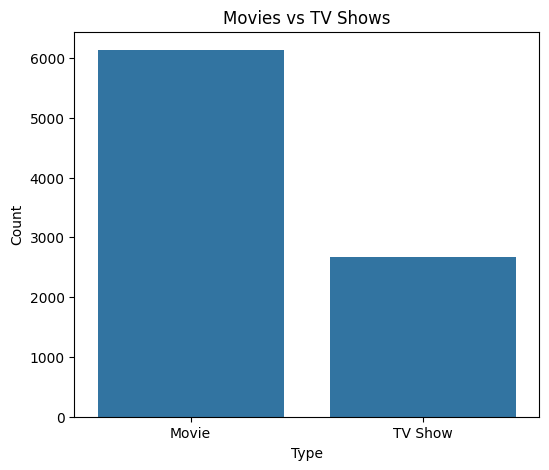

In [36]:
plt.figure(figsize=(6,5))
sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

### Observation

The dataset contains more Movies than TV Shows. This indicates that Netflix's library is primarily focused on movies.

## Question 2

### Which countries contribute the most Netflix content?

In [38]:
df["country"].value_counts().head(10)

,count
country,
United States,2812
India,972
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


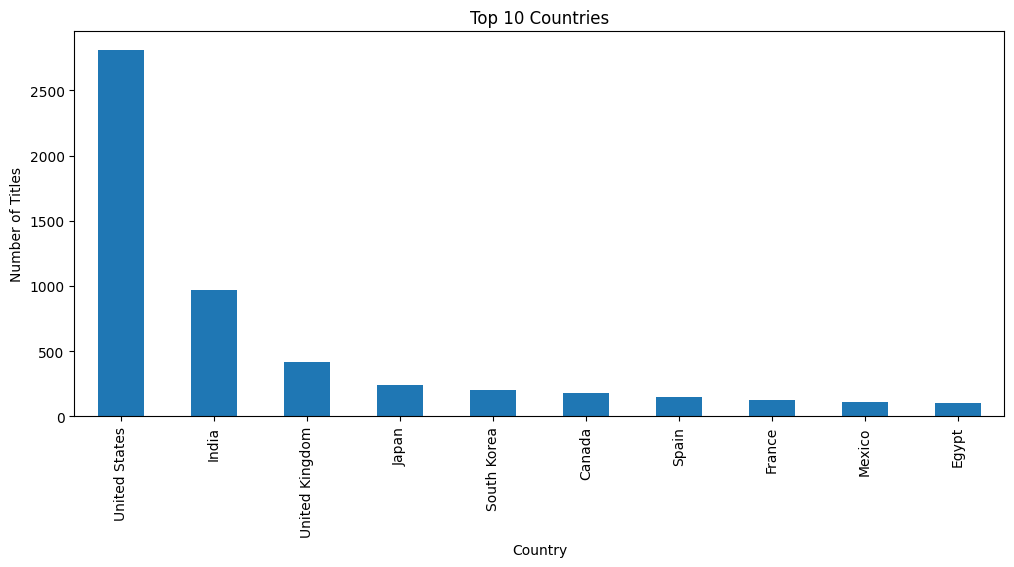

In [39]:
plt.figure(figsize=(12,5))

df["country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Number of Titles")

plt.show()

## Question 3

### What are the most common content ratings on Netflix?

In [40]:
df["rating"].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


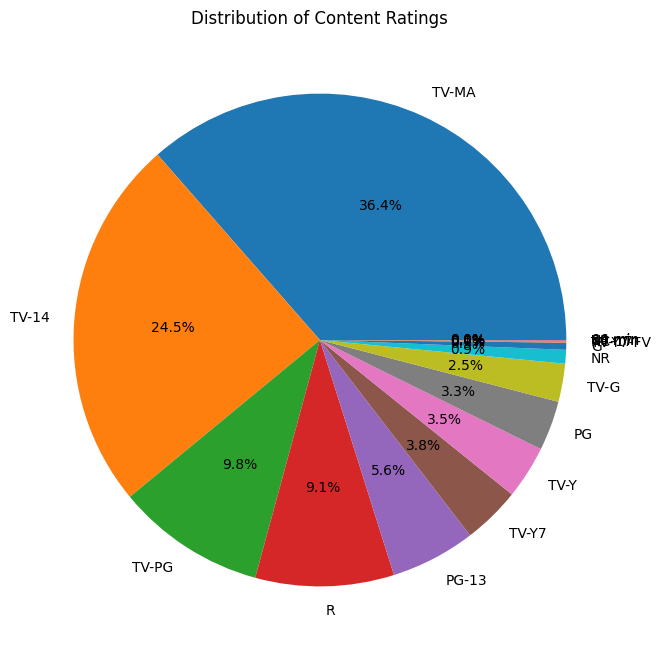

In [41]:
plt.figure(figsize=(8,8))

df["rating"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Distribution of Content Ratings")

plt.ylabel("")

plt.show()

### Observation

TV-MA is the most common rating in the dataset, indicating that a large portion of Netflix content is intended for mature audiences.

## Question 4

### How has the number of Netflix titles changed over the release years?

In [42]:
release_year = df["release_year"].value_counts().sort_index()

release_year

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1146
2019,1030


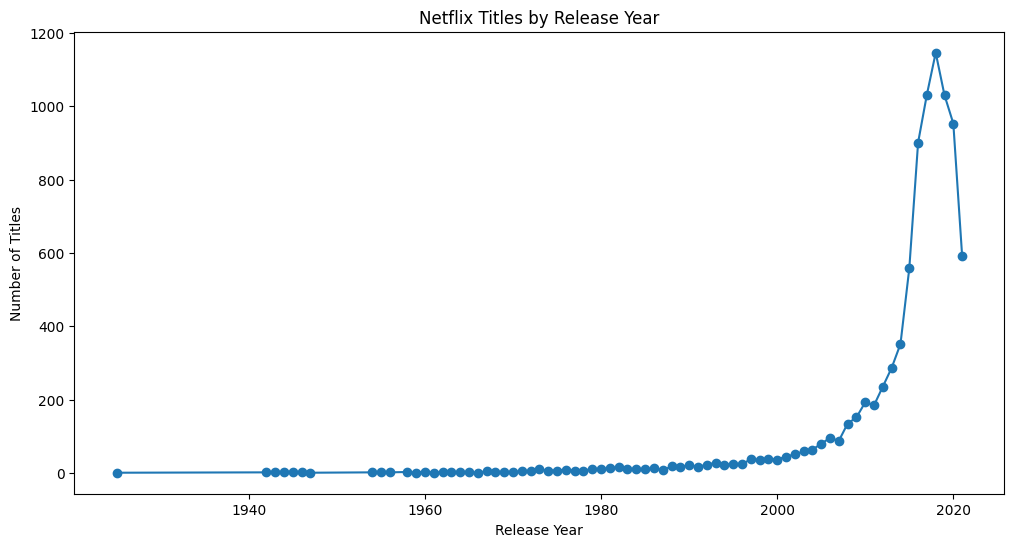

In [43]:
plt.figure(figsize=(12,6))

plt.plot(
    release_year.index,
    release_year.values,
    marker="o"
)

plt.title("Netflix Titles by Release Year")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.show()

### Observation

The number of Netflix titles has increased significantly after 2015, showing rapid growth in content production and acquisition.

## Question 5

### Which genres are the most common on Netflix?

In [44]:
top_genres = df["listed_in"].value_counts().head(10)

top_genres

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,219
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


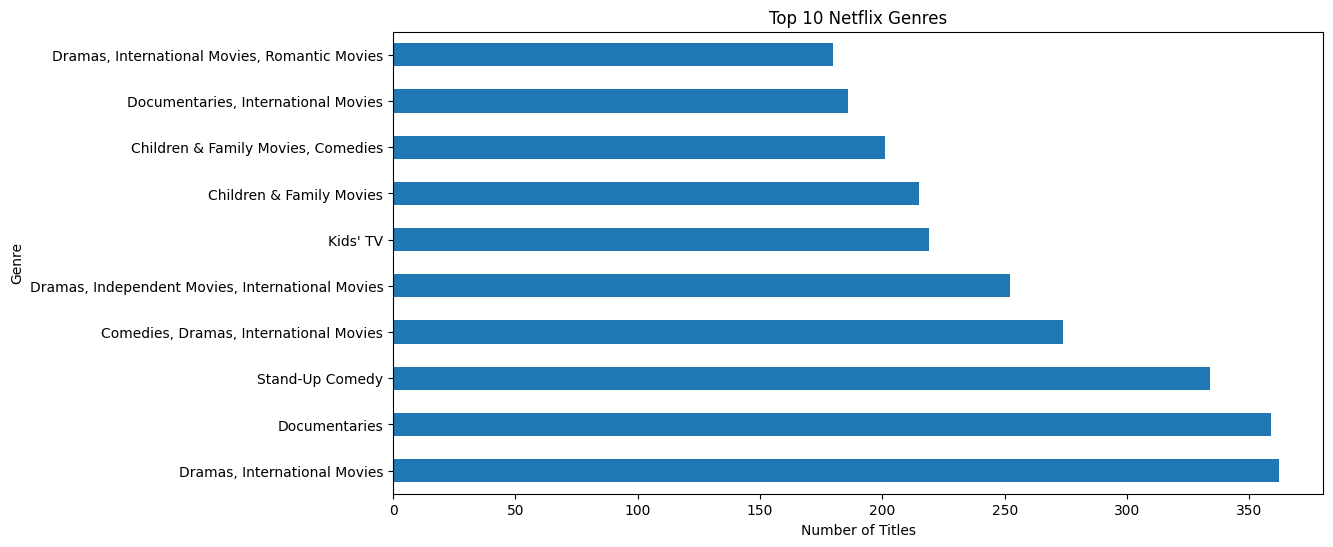

In [45]:
plt.figure(figsize=(12,6))

top_genres.plot(kind="barh")

plt.title("Top 10 Netflix Genres")

plt.xlabel("Number of Titles")

plt.ylabel("Genre")

plt.show()

### Observation

Drama, International Movies, and Comedy-related genres appear most frequently in the dataset, indicating that these categories dominate Netflix's content library.

## Question 6

### Which directors have directed the highest number of Netflix titles?

In [46]:
top_directors = df[df["director"] != "Unknown"]["director"].value_counts().head(10)

top_directors

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


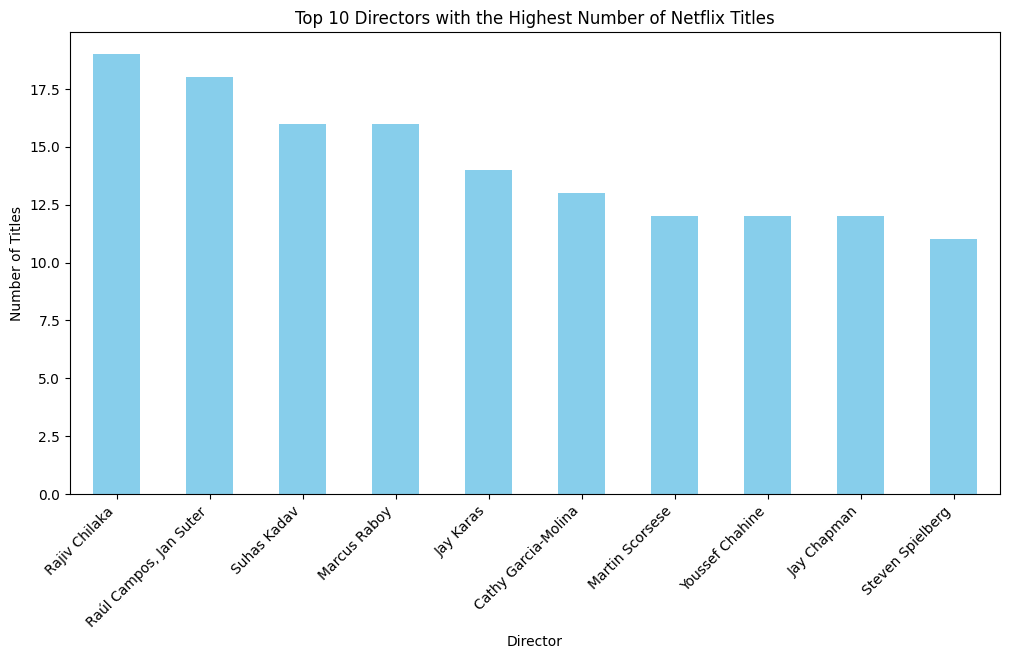

In [47]:
plt.figure(figsize=(12,6))

top_directors.plot(kind="bar", color="skyblue")

plt.title("Top 10 Directors with the Highest Number of Netflix Titles")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.show()

### Observation

A small number of directors have contributed multiple titles to Netflix, while most directors appear only once or twice. This suggests that Netflix collaborates repeatedly with certain directors but also features content from a wide variety of filmmakers.

# Business Insights

1. Netflix offers significantly more Movies than TV Shows.

2. The United States contributes the highest number of titles.

3. The number of titles released increased rapidly after 2015.

4. TV-MA is the most common content rating.

5. Drama-related genres are among the most frequently listed categories, indicating strong audience demand.

# Most Surprising Finding

The most surprising finding was the rapid increase in Netflix content after 2015. It was also interesting to observe that Movies greatly outnumber TV Shows, highlighting Netflix's strong focus on movie content.

# Conclusion

This project successfully performed Exploratory Data Analysis on the Netflix Movies and TV Shows dataset. The data was cleaned, analyzed, and visualized to identify meaningful trends and patterns. The findings provide valuable insights into Netflix's content distribution, release trends, ratings, and genres.